In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Day 7

In [85]:
data_lines = open("Day7-input.txt", "r").readlines()

In [95]:
dirname_list = []
filename_list = []

parent_dir = {}
filesize_dir = {}
dirsize_dir = {}

current_dir = "/"

In [87]:
for line in data_lines:
    splitted_line = line[:-1].split()
    
    if splitted_line[0] == '$': #command
        
        if splitted_line[1] == 'ls': #list contents
            continue
            
        elif splitted_line[1] == 'cd': #change directory
            if splitted_line[2] == "..": #move out one level
                current_dir = parent_dir[current_dir]
            else:
                dirname = splitted_line[2]
                if dirname not in dirname_list:
                    dirname_list.append(dirname)
                parent_dir[dirname] = current_dir # set the parent-child relation
                current_dir = dirname #move in to child               
                
    elif splitted_line[0] == 'dir': #directory inside the current directory
        dirname = splitted_line[1]
        if dirname not in dirname_list:
            dirname_list.append(dirname)
        parent_dir[dirname] = current_dir # set the parent-child relation

    else:
        filesize = int(splitted_line[0])
        filename = splitted_line[1]
        if filename not in filename_list:
            filename_list.append(filename)
        parent_dir[filename] = current_dir  
        filesize_dir[filename] = filesize
        
  

In [ ]:
for filename in filename_list: 
    while True:     
        dirname = parent_dir[filename]
        dirsize_dir[dirname] += filesize 
        filename
    

In [88]:
parent_dir

{'/': '/',
 'bhtvbj': '/',
 'bmlllrl': 'ngmqbc',
 'dhm': 'ngmqbc',
 'mnp': 'ngmqbc',
 'nwqgchw': 'ngmqbc',
 'dmd': 'bhtvbj',
 'fjblqtdp': 'bhtvbj',
 'mdmtpjq.wmf': 'bhtvbj',
 'qhm': 'czvcf',
 'rjr': 'czvcf',
 'smtrp': 'czvcf',
 'tbdsml': 'ngmqbc',
 'ngmqbc.mdj': 'dmd',
 'vqqcvgts.vrc': 'dmghrm',
 'czvcf': 'wntfhzqf',
 'jnzwf': 'czvcf',
 'lcpgtrc.dqm': 'hnrh',
 'nwqgchw.ppg': 'fjblqtdp',
 'rbj.twt': 'fjblqtdp',
 'cqzcp': 'czvcf',
 'bshmsns': 'cqzcp',
 'svhphd': 'cqzcp',
 'rbhprlgq.gbh': 'bshmsns',
 'lhfsc.lrh': 'nwqgchw',
 'ntsrpn': 'czvcf',
 'btmz': 'fpbrwnz',
 'bnqbdmm.dfh': 'qhm',
 'hqbhr': 'qhm',
 'hwvdlfl': 'qhm',
 'lvdrr': 'qhm',
 'nwcjvb': 'qhm',
 'rgtcchh': 'qhm',
 'wdcsgg.cjt': 'nwqgchw',
 'fcm': 'hqbhr',
 'ngmqbc': 'bmlllrl',
 'qnlssvn': 'hqbhr',
 'rdzsz.grd': 'hqbhr',
 'vvbgt': 'hqbhr',
 'wwzwqqh': 'hqbhr',
 'sfddtgp.flr': 'fcm',
 'gngvc': 'qnlssvn',
 'lbthznl.llq': 'qnlssvn',
 'nwqgchw.nlq': 'qnlssvn',
 'rrvwdw.nzv': 'qnlssvn',
 'rzssqpcj': 'qnlssvn',
 'rdzsz.hst': 'gngvc',


In [92]:
def get_dirsize(dirname):
    dirsize =0
    for filename in filename_list:
        if is_parent(dirname, filename) : # direct
            dirsize+=filesize_dir[filename]
    return dirsize

In [93]:
def is_parent(dirname , filename):
    if dirname == "/":
        
        return True
    elif dirname == parent_dir[filename]:
        return True
    
    elif filename =="/": #stopping condn
        return False
    else: 
        return is_parent(dirname, parent_dir[filename]) 
        
        

In [94]:
dirsize_list =[]
for dirname in dirname_list:
    dirsize_list.append(get_dirsize(dirname))
    #print(dirname, get_dirsize(dirname))

RecursionError: maximum recursion depth exceeded in comparison

In [84]:
dirsize_arr = np.array(dirsize_list)
np.sum(dirsize_arr[dirsize_arr<=1e5])

95437

# Day 8

In [2]:
data_lines = open("Day8-input.txt", "r").readlines()

In [3]:
forest_grid_list = []
for line in data_lines:
    #print(list(line))
    forest_grid_list.append(list(line)[:-1])
    
forest_grid = np.asarray(forest_grid_list, dtype = int)

In [4]:
visible_grid = np.zeros_like(forest_grid)

In [5]:
def visiblity(tree_posx, tree_posy):
    if np.all(forest_grid[:tree_posx, tree_posy]<forest_grid[tree_posx, tree_posy]):
        visible_grid[tree_posx, tree_posy] =1 
        #print("top")
    elif np.all(forest_grid[tree_posx+1:, tree_posy]<forest_grid[tree_posx, tree_posy]):
        visible_grid[tree_posx, tree_posy] =1 
        #print("bottom")
    elif np.all(forest_grid[tree_posx, :tree_posy]<forest_grid[tree_posx, tree_posy]):
        visible_grid[tree_posx, tree_posy] =1 
        #print("left")
    elif np.all(forest_grid[tree_posx, tree_posy+1:]<forest_grid[tree_posx, tree_posy]):
        visible_grid[tree_posx, tree_posy] =1 
        #print("right")

In [6]:
for tree_posx in range(forest_grid.shape[0]):
    for tree_posy in range(forest_grid.shape[1]):
        visiblity(tree_posx, tree_posy) 

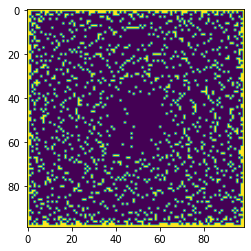

In [7]:
plt.imshow(visible_grid)

In [8]:
np.sum(visible_grid)

1823

In [9]:
def top_score(posx, posy):
    new_posx = posx -1
    score = 0
    if new_posx >=0: 
        while forest_grid[posx, posy]>= forest_grid[new_posx, posy]:
            score+=1
            if forest_grid[posx, posy] == forest_grid[new_posx, posy]:
                break
            new_posx-=1
            if new_posx <0:
                break
    return score

def down_score(posx, posy):
    new_posx = posx + 1
    score = 0
    
    if new_posx <forest_grid.shape[0]: 
        
        while forest_grid[posx, posy]>= forest_grid[new_posx, posy]:
            score+=1
            if forest_grid[posx, posy] == forest_grid[new_posx, posy]:
                break
            new_posx+=1
            if new_posx >= forest_grid.shape[0]:
                break
    return score

def left_score(posx, posy):
    new_posy = posy - 1
    score = 0
    
    if new_posy >=0:    
        while forest_grid[posx, posy]>= forest_grid[posx, new_posy]:
            score+=1
            if forest_grid[posx, posy] == forest_grid[posx, new_posy]:
                break
            new_posy-=1
            if new_posy <0:
                break
    return score

def right_score(posx, posy):
    new_posy = posy + 1
    score = 0
    if new_posy < forest_grid.shape[0]: 
        while forest_grid[posx, posy]>= forest_grid[posx, new_posy]:
            score+=1
            if forest_grid[posx, posy] == forest_grid[posx, new_posy]:
                break
            new_posy+=1
            if new_posy >=forest_grid.shape[0]:
                break
    return score




In [10]:
score_grid = np.zeros_like(forest_grid)
for posx in range(forest_grid.shape[0]):
    for posy in range(forest_grid.shape[1]):
        #print(posx,posy)
        score_grid[posx, posy] = top_score(posx, posy)*down_score(posx, posy)*left_score(posx, posy)*right_score(posx, posy)

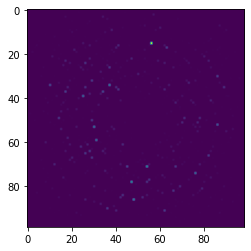

In [11]:
plt.imshow(score_grid)

In [13]:
np.max(score_grid)

211680

In [12]:
np.where(score_grid == np.max(score_grid))

(array([15]), array([56]))